In [1]:
import pandas as pd
from os import path
import matplotlib.pyplot as plt
from scipy import signal, interpolate
from scipy.spatial.distance import cdist
import numpy as np
import folium
from sklearn.preprocessing import MinMaxScaler


In [2]:
source_path = r"C:\Users\joses\Mi unidad\TRABAJO\49_profile_estimation\TRABAJO\car_models\synthetic_dataset\four_ramps_cwl"

win_len = 500

speed_stopped_th = 1. # m/s

# Data Extraction

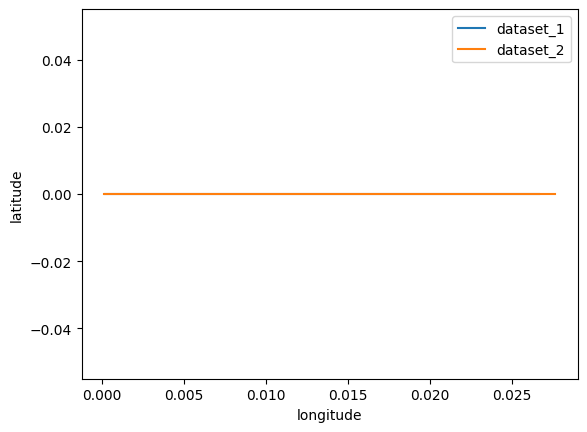

In [3]:
subtract_g = False
fs_acc = 100 # sps

# Dataset 1
i_ini, i_fin = 10, 235 # s
acc_orig_df_1 = pd.read_csv(path.join(source_path, "0/AccelerometerUncalibrated.csv")).iloc[i_ini*fs_acc:i_fin*fs_acc, :].reset_index()
if subtract_g:
    acc_orig_df_1['z'] = acc_orig_df_1['z'] - 9.81
loc_orig_df_1 = pd.read_csv(path.join(source_path, "0/Location.csv")).iloc[i_ini:i_fin, :].reset_index()
loc_orig_df_1 = loc_orig_df_1.loc[loc_orig_df_1['speed'] > speed_stopped_th].reset_index()

# Dataset 2
i_ini, i_fin = 10, 175 # s
acc_orig_df_2 = pd.read_csv(path.join(source_path, "1/AccelerometerUncalibrated.csv")).iloc[i_ini*fs_acc:i_fin*fs_acc, :].reset_index()
if subtract_g:
    acc_orig_df_2['z'] = acc_orig_df_2['z'] - 9.81
loc_orig_df_2 = pd.read_csv(path.join(source_path, "1/Location.csv")).iloc[i_ini:i_fin, :].reset_index()
loc_orig_df_2 = loc_orig_df_2.loc[loc_orig_df_2['speed'] > speed_stopped_th].reset_index()

plt.plot(loc_orig_df_1['longitude'], loc_orig_df_1['latitude'], label='dataset_1')
plt.plot(loc_orig_df_2['longitude'], loc_orig_df_2['latitude'], label='dataset_2')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.legend()
plt.show()

## Raw Visualization

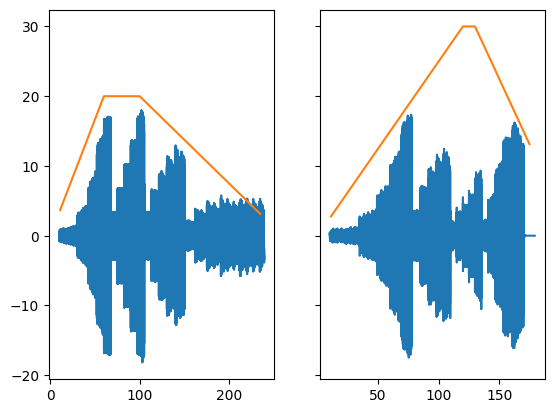

In [4]:
fig, ax = plt.subplots(1, 2, sharey='row')
ax[0].plot(acc_orig_df_1['seconds_elapsed'], acc_orig_df_1['z'])
ax[0].plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'])
ax[1].plot(acc_orig_df_2['seconds_elapsed'], acc_orig_df_2['z'])
ax[1].plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'])

# Feature extraction

Global spectrum

Text(0.5, 0, 'Frequency [Hz]')

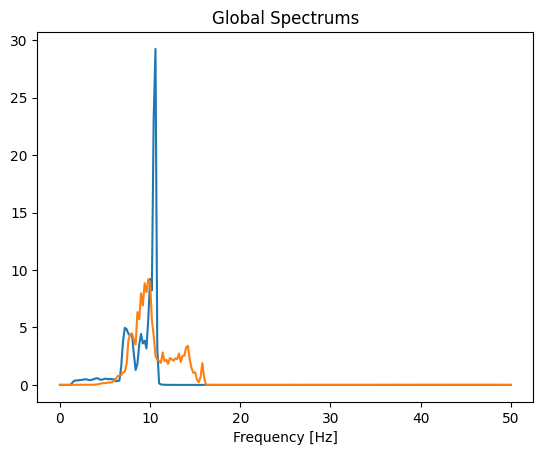

In [6]:
f = np.linspace(0, fs_acc/2, win_len//2 + 1)
global_spectrum_1 = signal.welch(acc_orig_df_1['z'].values, fs=fs_acc, nperseg=win_len, noverlap=win_len//2)[1]
global_spectrum_2 = signal.welch(acc_orig_df_2['z'].values, fs=fs_acc, nperseg=win_len, noverlap=win_len//2)[1]
fig, ax = plt.subplots(1, 1, sharex='col')
ax.plot(f, global_spectrum_1, label='global spectrum 1')
ax.plot(f, global_spectrum_2, label='global spectrum 2')
ax.set_title('Global Spectrums')
ax.set_xlabel('Frequency [Hz]')

## Spectrograms

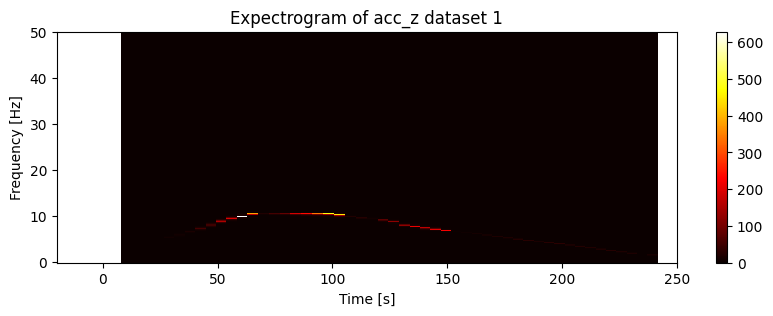

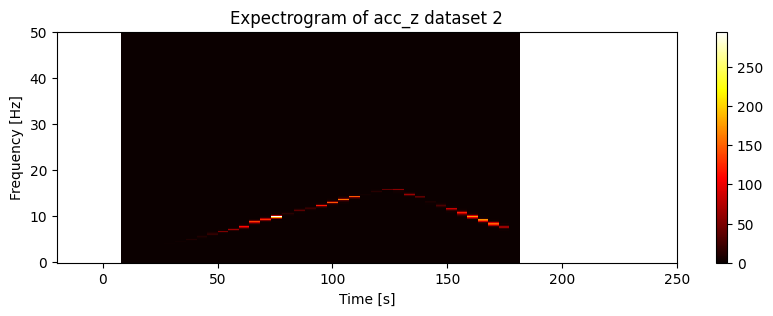

In [16]:
# plot expectrograms of acc_z
# Expectrograms

def plot_spectrogram(spectrogram_, ax=None, tlim=None, flim=None, title=None, spatial=False, x_index=False):
    f, t, Sxx = spectrogram_
    if x_index:
        t = np.arange(len(t))
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    im = ax.pcolormesh(t, f, Sxx, shading=None, cmap='hot')
    ax.set_ylabel('Frequency [Hz]' if not spatial else 'Spatial frequency [1/m]')
    ax.set_xlabel('Time [s]' if not x_index else 'Sample index')
    fig.colorbar(im, ax=ax)
    if tlim is not None:
        ax.set_xlim(tlim)
    if flim is not None:
        ax.set_ylim(flim)
    ax.set_title(title if title else 'Spectrogram')

    return ax

def get_spectrogram(acc_orig_df_n, fs, win_len):
    # Compute the spectrogram
    f, t, Sxx = signal.spectrogram(acc_orig_df_n['z'], fs=fs, nperseg=win_len)
    # Correct the time vector using seconds_elapsed
    t = np.interp(t, np.linspace(t[0], t[-1], len(acc_orig_df_n['seconds_elapsed'])), acc_orig_df_n['seconds_elapsed'])
    return (f, t, Sxx)

spectrogram_1 = get_spectrogram(acc_orig_df_1, fs=fs_acc, win_len=win_len)
spectrogram_2 = get_spectrogram(acc_orig_df_2, fs=fs_acc, win_len=win_len)

tmax = 250
tlim = (-20, tmax)
ax = plot_spectrogram(spectrogram_1, tlim=tlim, title='Expectrogram of acc_z dataset 1')
ax_ = plot_spectrogram(spectrogram_2, tlim=tlim, title='Expectrogram of acc_z dataset 2')

Normalized spectrograms

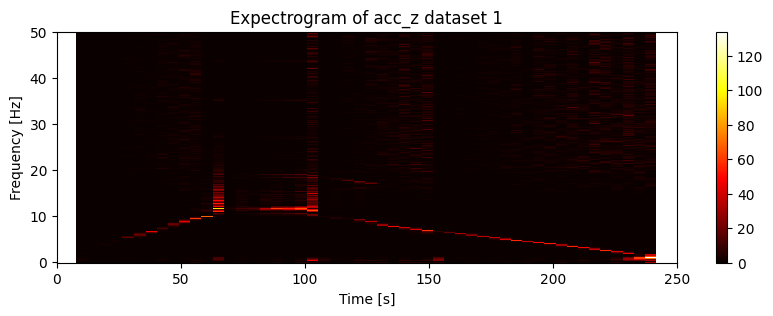

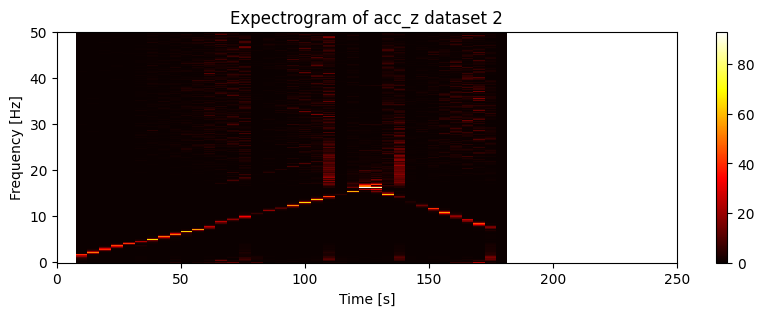

In [17]:
spectrogram_1_norm = (spectrogram_1[0], spectrogram_1[1], spectrogram_1[2]/global_spectrum_1.reshape(-1, 1))
spectrogram_2_norm = (spectrogram_2[0], spectrogram_2[1], spectrogram_2[2]/global_spectrum_2.reshape(-1, 1))

ax = plot_spectrogram(spectrogram_1_norm, tlim=(0, tmax), title='Expectrogram of acc_z dataset 1')
ax_ = plot_spectrogram(spectrogram_2_norm, tlim=(0, tmax), title='Expectrogram of acc_z dataset 2')

## Spatial Spectrograms
$f = \text{temporal frequency}$

$f_s = \text{spatial frequency}$

$v = \text{vehicle speed}$

$f = v f_s$

(0.0, 250.0)

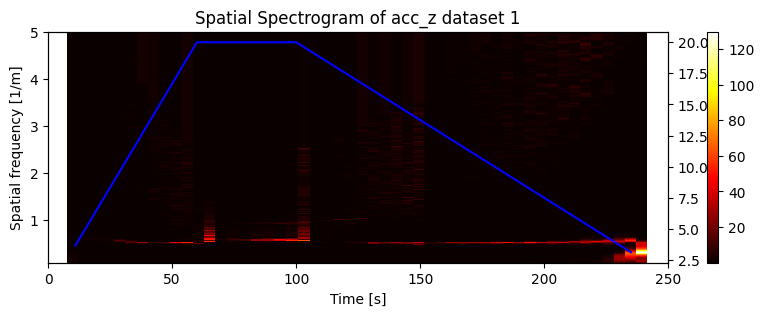

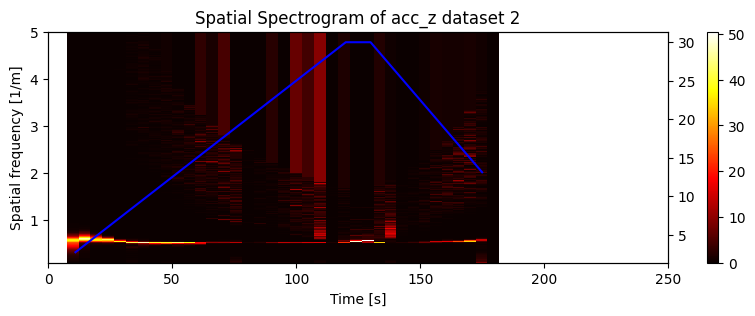

In [23]:
from typing import Union
min_wl = 0.2  # meter
max_wl = 10.0  # meter

def get_spatial_spectrogram(spectrogram: tuple, tv: np.ndarray, min_wl: float, max_wl: float) -> tuple:
    spatial_frequencies = np.linspace(1/max_wl, 1/min_wl, len(spectrogram[0]))
    f, t, Sxx = spectrogram
    Sxx_spatial = 0 * Sxx
    for i, t_ in enumerate(t):
        Sxx_spatial[:, i] = np.interp(np.interp(t_, tv[:,0], tv[:,1])*spatial_frequencies, f, Sxx[:, i])
    return spatial_frequencies, t, Sxx_spatial

spatial_spectrogram_1_norm = get_spatial_spectrogram(spectrogram_1_norm, loc_orig_df_1[['seconds_elapsed', 'speed']].values, min_wl, max_wl)
spatial_spectrogram_2_norm = get_spatial_spectrogram(spectrogram_2_norm, loc_orig_df_2[['seconds_elapsed', 'speed']].values, min_wl, max_wl)

# Plots
tlim = (0, tmax)
ax = plot_spectrogram(spatial_spectrogram_1_norm, tlim=tlim, title='Spatial Spectrogram of acc_z dataset 1', spatial=True)
ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'], color='blue', label='speed 1')
ax_twin.set_xlim(tlim)
ax_ = plot_spectrogram(spatial_spectrogram_2_norm, tlim=tlim, title='Spatial Spectrogram of acc_z dataset 2', spatial=True)
ax_twin_ = ax_.twinx()
ax_twin_.plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'], color='blue', label='speed 1')
ax_twin_.set_xlim(tlim)

In [24]:
# RMS of acceleration
def rolling_rms(acc_orig_df):
    acc2_cum = np.cumsum(acc_orig_df['z']**2)
    acc_rms = np.zeros(acc_orig_df.shape[0])
    for i in range(acc_orig_df.shape[0]-win_len):
        acc_rms[i+win_len] = np.sqrt((acc2_cum[i+win_len] - acc2_cum[i])/win_len)
    acc_feat_df = pd.DataFrame(data=np.vstack((acc_orig_df['seconds_elapsed'].values, acc_rms)).T, 
                                columns=['seconds_elapsed', 'z_rolling_rms']).fillna(0)
    acc_feat_df.reset_index(inplace=True)
    first_non_zero = np.nonzero(acc_feat_df['z_rolling_rms'].values)[0][0]
    acc_feat_df['z_rolling_rms'].values[:first_non_zero] = acc_feat_df['z_rolling_rms'].values[first_non_zero]
    return acc_feat_df

acc_feat_df_1, acc_feat_df_2 = rolling_rms(acc_orig_df_1), rolling_rms(acc_orig_df_2)


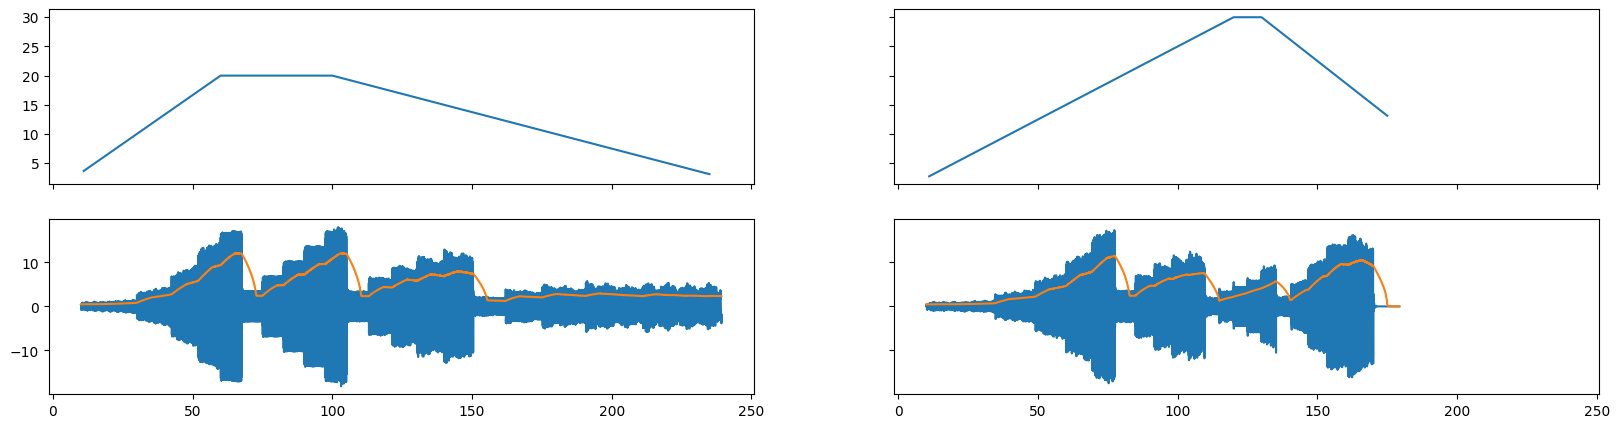

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(20, 5), sharex='all', sharey='row')
ax[0,0].plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'])
ax[1,0].plot(acc_orig_df_1['seconds_elapsed'], acc_orig_df_1['z'])
ax[1,0].plot(acc_feat_df_1['seconds_elapsed'], acc_feat_df_1['z_rolling_rms'])
# ax[1,0].set_xlim([0, 200])
ax[0,1].plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'])
ax[1,1].plot(acc_orig_df_2['seconds_elapsed'], acc_orig_df_2['z'])
ax[1,1].plot(acc_feat_df_2['seconds_elapsed'], acc_feat_df_2['z_rolling_rms'])
# ax[1,1].set_xlim([0, 60])
plt.show()

### Low frequency features

In [26]:
def calc_features_lf_n(loc_orig_df_n, acc_feat_df_n, spectrogram_, spatial_spectrogram_):
    features_lf_n = loc_orig_df_n.loc[:, :]
    features_lf_n['z_rolling_rms'] = \
    np.interp(x=loc_orig_df_n['seconds_elapsed'], 
              xp=acc_feat_df_n['seconds_elapsed'].values-((win_len/fs_acc)/2), fp=acc_feat_df_n['z_rolling_rms'])
    features_lf_n = features_lf_n.drop(columns=['level_0']).reset_index()

    # add spectrogram features (1 column for each frequency bin)
    f, t, Sxx = spectrogram_
    interp_spectrogram = np.array([
        np.interp(x=loc_orig_df_n['seconds_elapsed'], xp=t, fp=Sxx[i])
        for i in range(Sxx.shape[0])
    ])

    spectro_cols = [f'spectrogram_{f[i]}Hz' for i in range(Sxx.shape[0])]
    spectro_df = pd.DataFrame(interp_spectrogram.T, columns=spectro_cols)

    features_lf_n = pd.concat([features_lf_n.reset_index(drop=True), spectro_df], axis=1)

    # add spatial spectrogram (1 column for each spatial frequency bin)
    fs, t, Sxx_spatial = spatial_spectrogram_
    interp_spectrogram_spatial = np.array([
        np.interp(x=loc_orig_df_n['seconds_elapsed'], xp=t, fp=Sxx_spatial[i])
        for i in range(Sxx_spatial.shape[0])
    ])
    spectro_cols_spatial = [f'spatial_spectrogram_{fs[i]}/m' for i in range(Sxx_spatial.shape[0])]
    spectro_df_spatial = pd.DataFrame(interp_spectrogram_spatial.T, columns=spectro_cols_spatial)
    
    features_lf_n = pd.concat([features_lf_n.reset_index(drop=True), spectro_df_spatial], axis=1)

    return features_lf_n


features_lf_1 = calc_features_lf_n(loc_orig_df_1, acc_feat_df_1, spectrogram_1_norm, spatial_spectrogram_1_norm) 
features_lf_2 = calc_features_lf_n(loc_orig_df_2, acc_feat_df_2, spectrogram_2_norm, spatial_spectrogram_2_norm)


# fig, ax = plt.subplots(2, 2, figsize=(20, 10), sharex='all', sharey='row')
# ax[0,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['speed'])
# ax[0,0].set_ylabel('speed (m/s)')
# ax[1,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['z_rolling_rms'])
# ax[1,0].set_ylabel('rms acc. (m/s$^2$)')
# ax[0,1].plot(features_lf_2['seconds_elapsed'], features_lf_2['speed'])
# ax[1,1].plot(features_lf_2['seconds_elapsed'], features_lf_2['z_rolling_rms'])
# ax[1,0].set_xlabel('time (s)')
# ax[1,1].set_xlabel('time (s)')
# plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
# ax[0].plot(features_lf_1['z_rolling_rms'], features_lf_1['speed'], linestyle='-', marker='.')
# ax[0].set_xlabel('rms acc. (m/s$^2$)')
# ax[0].set_ylabel('speed (m/s)')
# ax[1].plot(features_lf_2['z_rolling_rms'], features_lf_2['speed'], linestyle='-', marker='.')
# ax[1].set_xlabel('rms acc. (m/s$^2$)')
# plt.show()

### Location matching

In [27]:
def times_matches_1_n(loc_orig_df_1, loc_orig_df_n, features_lf_n):
    # Extract coordinates as arrays
    coords_orig = loc_orig_df_1[['latitude', 'longitude']].values
    coords_dest = loc_orig_df_n[['latitude', 'longitude']].values

    # Compute pairwise distances
    distances = cdist(coords_orig, coords_dest, metric='euclidean')

    # Find the nearest point for each origin point
    nearest_indices = distances.argmin(axis=1)
    nearest_distances = distances.min(axis=1)

    # Build a dictionary of time matches
    time_matches_dict = {}
    for i, (dist, idx) in enumerate(zip(nearest_distances, nearest_indices)):
        orig_time = loc_orig_df_1.iloc[i]['seconds_elapsed']
        dest_time = loc_orig_df_n.iloc[idx]['seconds_elapsed']
        time_matches_dict[orig_time] = dest_time

    # location matching
    loc_orig_df_n_matched = loc_orig_df_1.copy()
    for index, row in loc_orig_df_1.iterrows():
        seconds_elapsed_1 = row['seconds_elapsed']
        if index == len(loc_orig_df_n_matched):
            break
        loc_orig_df_n_matched.iloc[index] = loc_orig_df_n.loc[loc_orig_df_n['seconds_elapsed'] == time_matches_dict[seconds_elapsed_1]].values[0]

    # feature matching
    features_lf_n_matched = features_lf_1.copy()
    for index, row in features_lf_1.iterrows():
        seconds_elapsed_1 = row['seconds_elapsed']
        features_lf_n_matched.iloc[index] = features_lf_n.loc[features_lf_n['seconds_elapsed'] == time_matches_dict[seconds_elapsed_1]].values[0]

    return time_matches_dict, loc_orig_df_n_matched, features_lf_n_matched


time_matches_dict, loc_orig_df_2_matched, features_lf_2_matched = times_matches_1_n(loc_orig_df_1, loc_orig_df_2, features_lf_2)


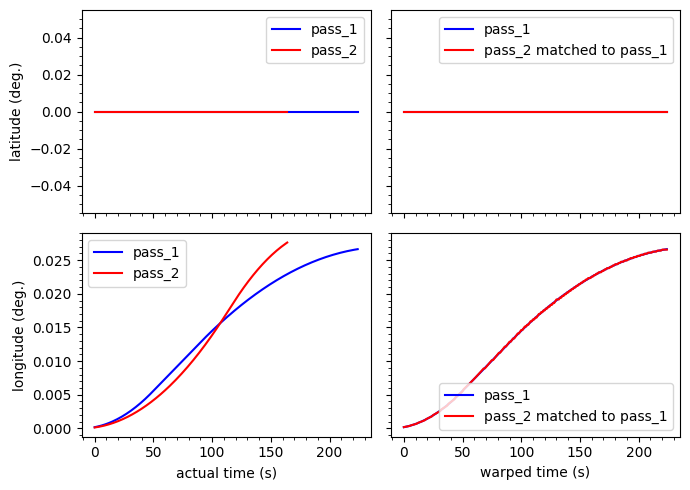

In [28]:

fig, ax = plt.subplots(2, 2, figsize=(7, 5), sharey='row', sharex='col')

ax[0,0].plot(loc_orig_df_1['latitude'].values, color='blue', label='pass_1')
ax[0,0].plot(loc_orig_df_2['latitude'].values, color='red', label='pass_2')
ax[1,0].plot(loc_orig_df_1['longitude'].values, color='blue', label='pass_1')
ax[1,0].plot(loc_orig_df_2['longitude'].values, color='red',  label='pass_2')


ax[0,1].plot(loc_orig_df_1['latitude'].values, color='blue', label='pass_1')
ax[0,1].plot(loc_orig_df_2_matched['latitude'].values, color='red',  label='pass_2 matched to pass_1')
ax[1,1].plot(loc_orig_df_1['longitude'].values, color='blue', label='pass_1')
ax[1,1].plot(loc_orig_df_2_matched['longitude'].values, color='red',  label='pass_2 matched to pass_1')

ax[0,0].set_ylabel('latitude (deg.)')
ax[1,0].set_ylabel('longitude (deg.)')
ax[1,0].set_xlabel('actual time (s)')
ax[1,1].set_xlabel('warped time (s)')

for __ in ax:
    for _ in __:
        _.minorticks_on()
        _.legend()

fig.tight_layout()
plt.show()
fig.savefig('location_based_dtw.pdf')

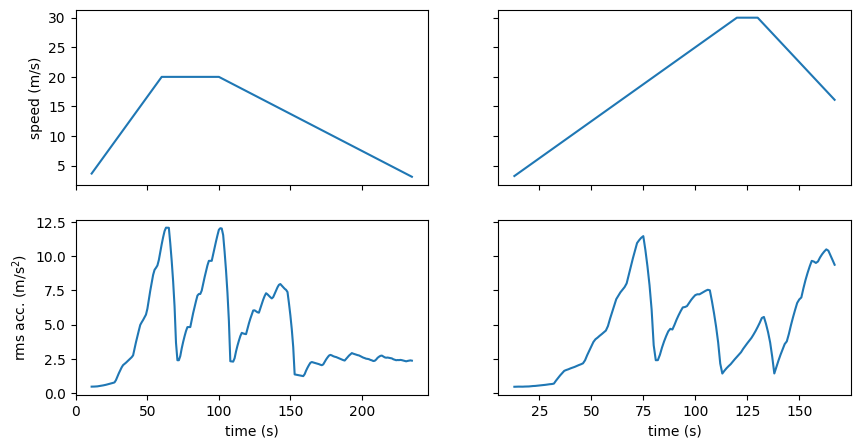

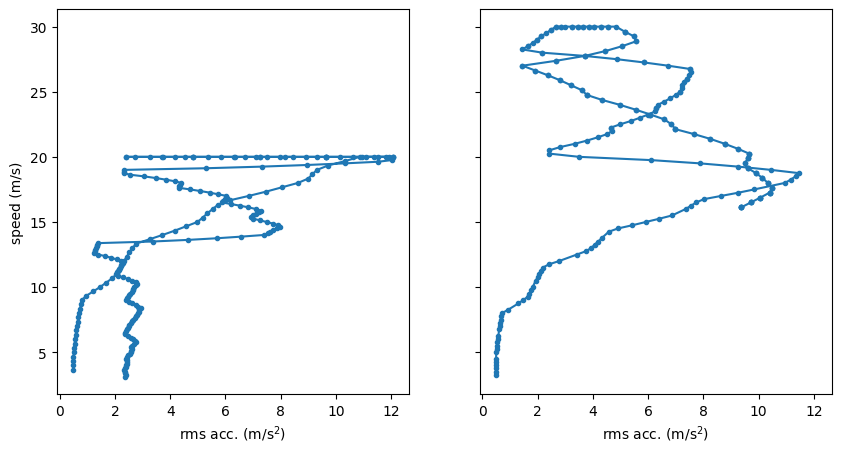

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5), sharex='col', sharey='row')
ax[0,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['speed'])
ax[0,0].set_ylabel('speed (m/s)')
ax[1,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['z_rolling_rms'])
ax[0,1].plot(features_lf_2_matched['seconds_elapsed'], features_lf_2_matched['speed'])
ax[1,1].plot(features_lf_2_matched['seconds_elapsed'], features_lf_2_matched['z_rolling_rms'])
ax[1,0].set_ylabel('rms acc. (m/s$^2$)')
ax[1,0].set_xlabel('time (s)')
ax[1,1].set_xlabel('time (s)')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
ax[0].plot(features_lf_1['z_rolling_rms'], features_lf_1['speed'], linestyle='-', marker='.')
ax[0].set_xlabel('rms acc. (m/s$^2$)')
ax[0].set_ylabel('speed (m/s)')
ax[1].plot(features_lf_2_matched['z_rolling_rms'], features_lf_2_matched['speed'], linestyle='-', marker='.')
ax[1].set_xlabel('rms acc. (m/s$^2$)')
plt.show()

# Matched spectrograms

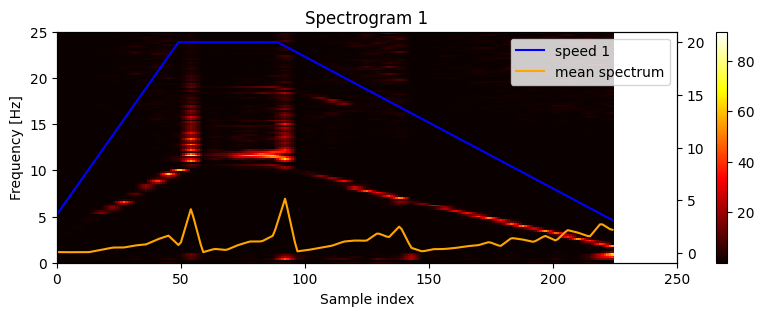

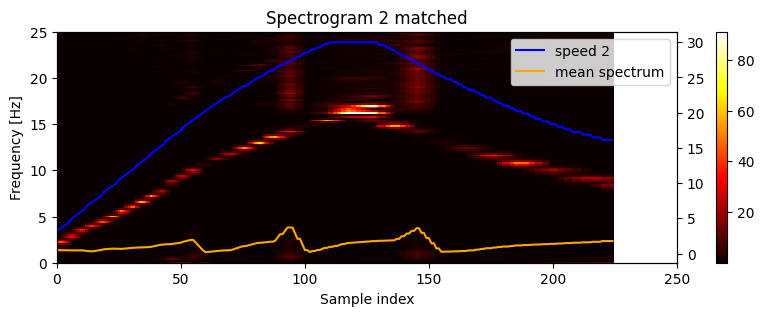

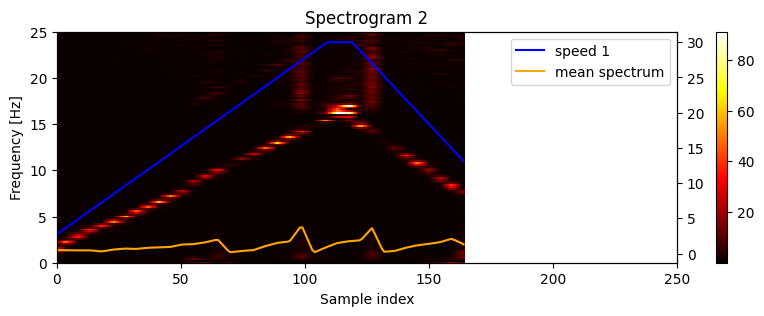

In [33]:
# Matched spectrograms

spectrogram_from_lf_1_ = features_lf_1.loc[:, ['seconds_elapsed'] + [col for col in features_lf_1.columns if ('spectrogram_' in col and 'Hz' in col)]].values
spectrogram_from_lf_1 = (np.linspace(0, fs_acc/2, spectrogram_from_lf_1_.shape[1]-1), spectrogram_from_lf_1_[:,0], spectrogram_from_lf_1_[:, 1:].T)
spectrogram_from_lf_2_ = features_lf_2.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2.columns if ('spectrogram_' in col and 'Hz' in col)]].values
spectrogram_from_lf_2 = (np.linspace(0, fs_acc/2, spectrogram_from_lf_2_.shape[1]-1), spectrogram_from_lf_2_[:,0], spectrogram_from_lf_2_[:, 1:].T)
spectrogram_from_lf_2_matched_ = features_lf_2_matched.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2_matched.columns if ('spectrogram_' in col and 'Hz' in col)]].values
spectrogram_from_lf_2_matched = (np.linspace(0, fs_acc/2, spectrogram_from_lf_2_matched_.shape[1]-1), spectrogram_from_lf_1_[:,0], spectrogram_from_lf_2_matched_[:, 1:].T)

tmax = 250
ax = plot_spectrogram(spectrogram_from_lf_1, tlim=(0, tmax), flim=(0, 25), title='Spectrogram 1', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_1['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_1[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()
ax = plot_spectrogram(spectrogram_from_lf_2_matched, tlim=(0, tmax), flim=(0, 25), title='Spectrogram 2 matched', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2_matched['speed'], color='blue', label='speed 2')
ax_twin.plot(np.mean(spectrogram_from_lf_2_matched[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()
ax = plot_spectrogram(spectrogram_from_lf_2, tlim=(0, tmax), flim=(0, 25), title='Spectrogram 2', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_2[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()


## Velocity normalized spectrograms

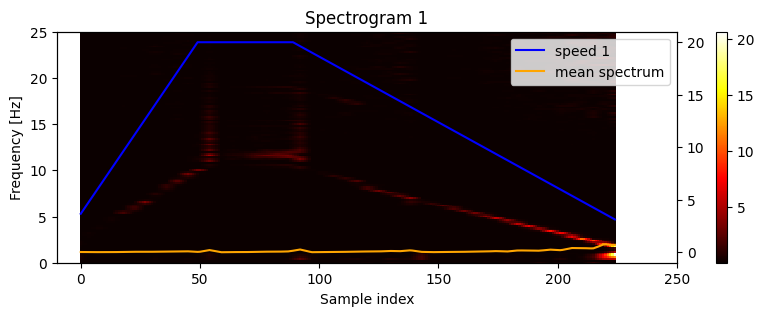

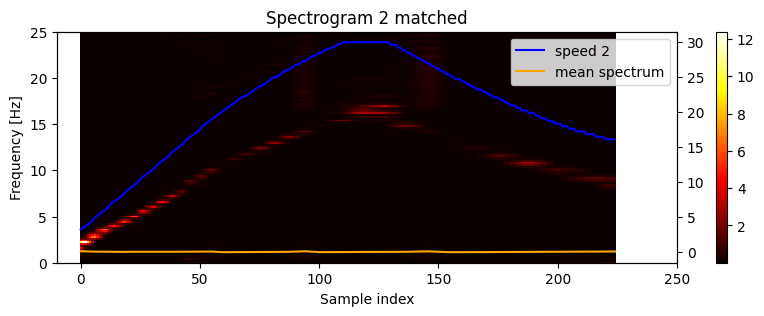

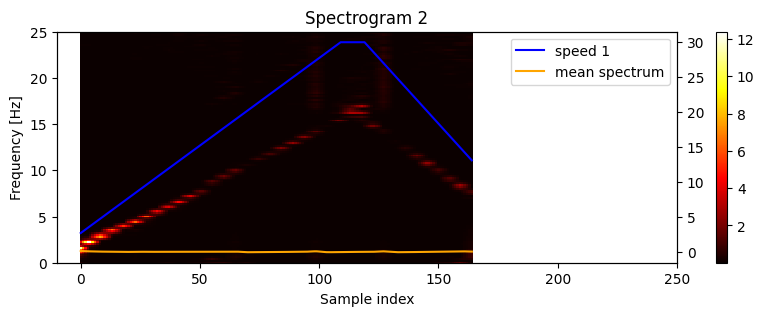

In [35]:
spectrogram_from_lf_1_vel_norm = (
    spectrogram_from_lf_1[0], spectrogram_from_lf_1[1], 
    spectrogram_from_lf_1[2] / features_lf_1['speed'].values.reshape(1, -1)
    )
spectrogram_from_lf_2_matched_vel_norm = (
    spectrogram_from_lf_2_matched[0], spectrogram_from_lf_2_matched[1], 
    spectrogram_from_lf_2_matched[2] / features_lf_2_matched['speed'].values.reshape(1, -1)
    )
spectrogram_from_lf_2_vel_norm = (
    spectrogram_from_lf_2[0], spectrogram_from_lf_2[1], 
    spectrogram_from_lf_2[2] / features_lf_2['speed'].values.reshape(1, -1)
    )

ilim = (-10, 250)
ax = plot_spectrogram(spectrogram_from_lf_1_vel_norm, tlim=ilim, flim=(0, 25), title='Spectrogram 1', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_1['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_1_vel_norm[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

ax = plot_spectrogram(spectrogram_from_lf_2_matched_vel_norm, tlim=ilim, flim=(0, 25), title='Spectrogram 2 matched', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2_matched['speed'], color='blue', label='speed 2')
ax_twin.plot(np.mean(spectrogram_from_lf_2_matched_vel_norm[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

ax = plot_spectrogram(spectrogram_from_lf_2_vel_norm, tlim=ilim, flim=(0, 25), title='Spectrogram 2', x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(features_lf_2['speed'], color='blue', label='speed 1')
ax_twin.plot(np.mean(spectrogram_from_lf_2_vel_norm[2], axis=0), label='mean spectrum', color='orange')
ax_twin.legend()

## Matched Spatial spectrograms
$\frac{1}{s} \frac{s}{m}=\frac{1}{m}$


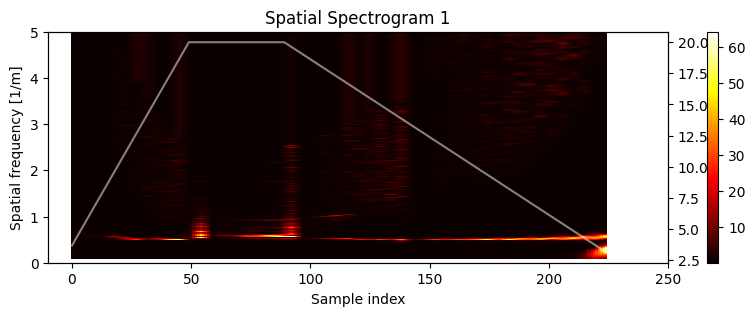

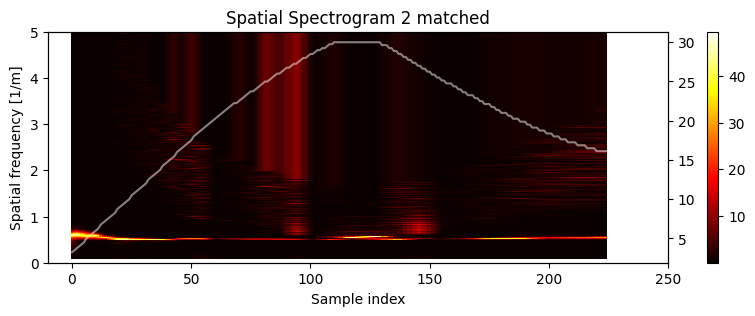

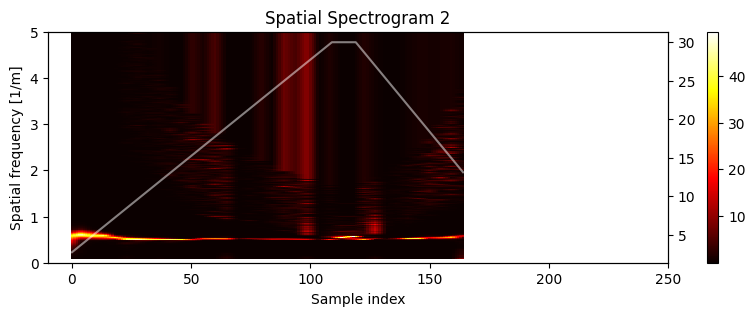

In [36]:
# Matched spatial spectrograms

spatial_spectrogram_from_lf_1_ = features_lf_1.loc[:, ['seconds_elapsed'] + [col for col in features_lf_1.columns if 'spatial_spectrogram_' in col]].values
spatial_spectrogram_from_lf_1 = (np.linspace(1/max_wl, 1/min_wl, spatial_spectrogram_from_lf_1_.shape[1]-1), spatial_spectrogram_from_lf_1_[:,0], spatial_spectrogram_from_lf_1_[:, 1:].T)
spatial_spectrogram_from_lf_2_ = features_lf_2.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2.columns if 'spatial_spectrogram_' in col]].values
spatial_spectrogram_from_lf_2 = (np.linspace(1/max_wl, 1/min_wl, spatial_spectrogram_from_lf_2_.shape[1]-1), spatial_spectrogram_from_lf_2_[:,0], spatial_spectrogram_from_lf_2_[:, 1:].T)
spatial_spectrogram_from_lf_2_matched_ = features_lf_2_matched.loc[:, ['seconds_elapsed'] + [col for col in features_lf_2_matched.columns if 'spatial_spectrogram_' in col]].values
spatial_spectrogram_from_lf_2_matched = (np.linspace(1/max_wl, 1/min_wl, spatial_spectrogram_from_lf_2_matched_.shape[1]-1), spatial_spectrogram_from_lf_1_[:,0], spatial_spectrogram_from_lf_2_matched_[:, 1:].T)

tlim = (-10, 250)
ax = plot_spectrogram(spatial_spectrogram_from_lf_1, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram 1', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df_1['speed'], color='white', label='speed', alpha=0.5)
ax = plot_spectrogram(spatial_spectrogram_from_lf_2_matched, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram 2 matched', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df_2_matched['speed'], color='white', label='speed', alpha=0.5)
ax = plot_spectrogram(spatial_spectrogram_from_lf_2, tlim=tlim, flim=(0, 5), title='Spatial Spectrogram 2', spatial=True, x_index=True)
ax_twin = ax.twinx()
ax_twin.plot(loc_orig_df_2['speed'], color='white', label='speed', alpha=0.5)